# EDA - Exploratory Data Analysis

Para los audios primero lo hemos cargado con [librosa](https://librosa.org/doc/latest/index.html), y para cada audio hemos definido 6 columnas:


1.   **archivo**: los audios nos siven como identificador único en el proyecto.
2.   **y**: la amplitud del sonido en cada instante de tiempo.
3.   **sr**: se corresponde con la tasa de muestreo
4.   **vocal**: la vocal que se pronuncia en dicho audio (a,e,i,o,u).
5.   **género**: el género del locutor del audio (hombre o mujer).
6.   **duración**: el tiempo en segundos que dura el audio, es una característica calculada por nosotros (`len(y)/sr`).

Este proceso de carga de audios se encuentra en la función [`carga_path_audios(path)`](------) del fichero `audio_carga.py` que recibe como parámetro la ruta donde se encuentran los audios.






Para no volver a leer todos los audios hemos creado una función que guarda el dataframe en un fichero con formato `.parquet` y cuyo nombre podemos ponerlo nosotros con el parámetro de la función [`guardar_df(df,nombre,path_destino)`](https://drive.google.com/file/d/1CZpm9qOjZGNgdTOBXFAdWBFhJ4W_FgZd/view?usp=drive_link) del fichero `audio_carga.py` (también añadimos al nombre del fichero el número de audios que tiene)

**Nota**: Los audios deben tener una nomenclatura y formato específico, por ejemplo : u_mujer_hdds.opus

<div align="center">
vocal_genero.formato
</div>

Debido a esta premisa, hemos definido una función en `audio_carga.py` llamada `verificar_audios` que valida el formato de los audios

In [1]:
path_data = '../data/'
path_audios = path_data + '/Audios'

## Librerías y funciones

In [24]:
from audio_carga import carga_path_audios , verificar_audios
from preprocessing import quitar_silencio

import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
verificar_audios(path_audios)


Resumen del directorio:
  Archivos válidos: 131
  Archivos inválidos: 0
  Formatos encontrados: {'.ogg': 106, '.opus': 25}


{'.ogg': 106, '.opus': 25}

Observamos que los audios siguen las premisas anteriormente estipuladas, vamos a proceder a cargar los audios y a estructurar el dataset

## Carga de los audios

In [4]:
df = carga_path_audios(path_audios)


Se cargaron 131 audios exitosamente


In [5]:
df.head()

,archivo,y,sr,vocal,genero,duracion
0,u_hombre_apqnclapfurnchsa.ogg,"[2.1537335e-06, -3.0066053e-06, 9.361513e-07, ...",22050,u,hombre,1.017823
1,i_hombre_jk51.ogg,"[2.1537335e-06, -3.0066053e-06, 9.361513e-07, ...",22050,i,hombre,1.057823
2,u_hombre_jc15.ogg,"[2.1537294e-06, -3.0066062e-06, 9.3614733e-07,...",22050,u,hombre,1.773515
3,i_hombre_nxcvkje.opus,"[2.1537337e-06, -3.0066053e-06, 9.3615347e-07,...",22050,i,hombre,1.457823
4,a_mujer_jk3.ogg,"[2.1537342e-06, -3.0066049e-06, 9.361498e-07, ...",22050,a,mujer,1.853515


## Eliminación del silencio

Vamos a visualizar la señal de un audio, encontramos que tienen silencio antes y después de que se enuncie la vocal (esto lo hemos observado no solo visualizando un ejemplo, sino que a la hora de recolectar los audios, observamos que muchos audios tenían silencio)

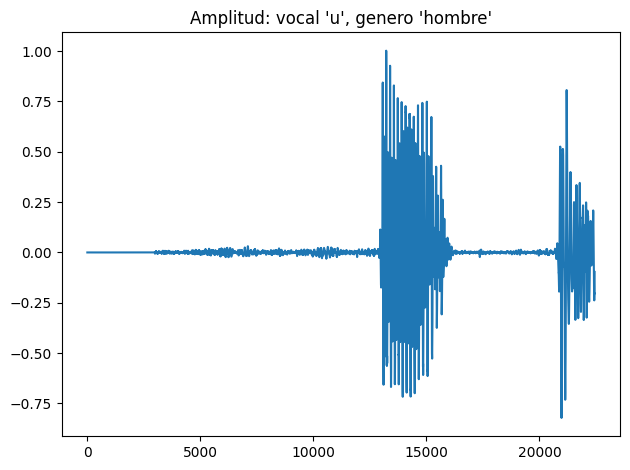

In [6]:
df_0 = df.iloc[0]
vocal = df_0["vocal"]
genero = df_0["genero"]
amplitud = df_0["y"]

plt.figure()
plt.plot(amplitud)
plt.title("Amplitud: vocal '{}', genero '{}'".format(vocal, genero))
plt.tight_layout()
plt.show()

Este silencio solo añadiría ruido al modelo, así que lo suprimimos. Para suprimirlo vamos a emplear una función definida en `preprocessing.py` llamada `quitar_silencio(y,frame_size,hop_size,threshold)`.

El procedimiento consiste en dividir el audio en ventanas (frames) de 1024 muestras
con un desplazamiento (hop) de 512 muestras entre ventanas consecutivas. Para cada
frame se calcula su energía media como la media del cuadrado de las amplitudes que
lo componen, y se compara con la energía máxima registrada en todo el audio. Solo se
conservan los frames cuya energía supera el 1 % de ese máximo; el resto se descarta por
considerarse silencio o ruido de fondo de baja intensidad.

In [7]:
df_sin_silencio = df.copy()
df_sin_silencio['y']= df_sin_silencio['y'].apply(lambda x: quitar_silencio(x))

<Figure size 1400x500 with 0 Axes>

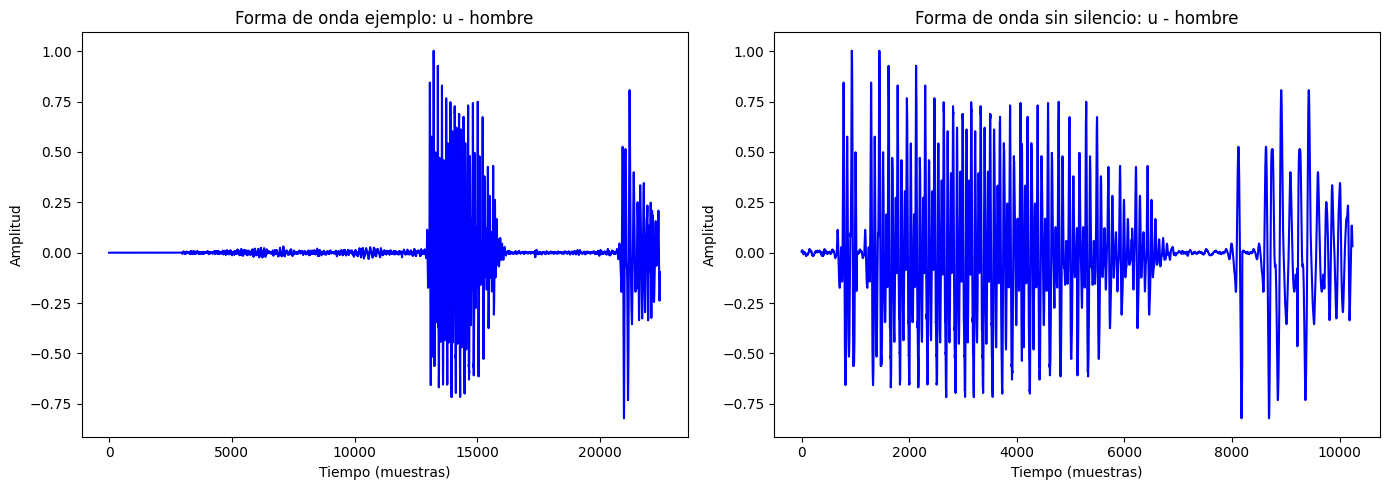

In [9]:
plt.figure(figsize=(14,5))
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(amplitud, color='blue')
axes[0].set_title(f"Forma de onda ejemplo: {vocal} - {genero}")
axes[0].set_xlabel("Tiempo (muestras)")
axes[0].set_ylabel("Amplitud")

audio = np.array(df_sin_silencio.iloc[0]['y'])
axes[1].plot(audio, color='blue')
axes[1].set_title(f"Forma de onda sin silencio: {vocal} - {genero}")
axes[1].set_xlabel("Tiempo (muestras)")
axes[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

## Detección y eliminación de outliers

Una vez eliminado el silencio, se analizó la distribución de las longitudes resultantes
de los audios para detectar valores atípicos. Se empleó el criterio del rango intercuartílico
(IQR): se identificaron como outliers aquellos audios con una longitud inferior a Q1 − 1,5 ·
IQR o superior a Q3 + 1,5 · IQR. Este criterio es más robusto que el uso de la media y la
desviación estándar cuando la distribución puede no ser gaussiana, como es habitual con
duraciones de audio.

In [18]:
sample_rate = 22050
audio_lengths = df_sin_silencio['y'].apply(lambda x: len(x))

In [19]:
q1, q3 = audio_lengths.quantile([0.25, 0.75])
iqr = q3 - q1

outliers = audio_lengths[(audio_lengths < q1 - 1.5 * iqr) | (audio_lengths > q3 + 1.5 * iqr)]

In [20]:
outliers_in_secs = [round(x / sample_rate, 3) for x in outliers.to_list()]

In [21]:
"s, ".join([str(val) for val in outliers_in_secs]) + "s"

'0.929s, 1.115s, 1.161s, 0.975s, 1.393s, 0.975s, 1.3s, 1.765s, 1.115s, 0.929s, 1.115s, 3.158s, 1.486s'

In [22]:
print(f"DataFrame size before: {df_sin_silencio.shape[0]}")

df_sin_silencio_outliers = df.drop(index=outliers.index).reset_index()
print(f"DataFrame size after outlier removal: {df_sin_silencio_outliers.shape[0]}")

DataFrame size before: 131
DataFrame size after outlier removal: 118


El análisis detectó 13 audios atípico. Tras esta limpieza, el dataset quedó compuesto por 118 muestras.

## Análisis de la distribución

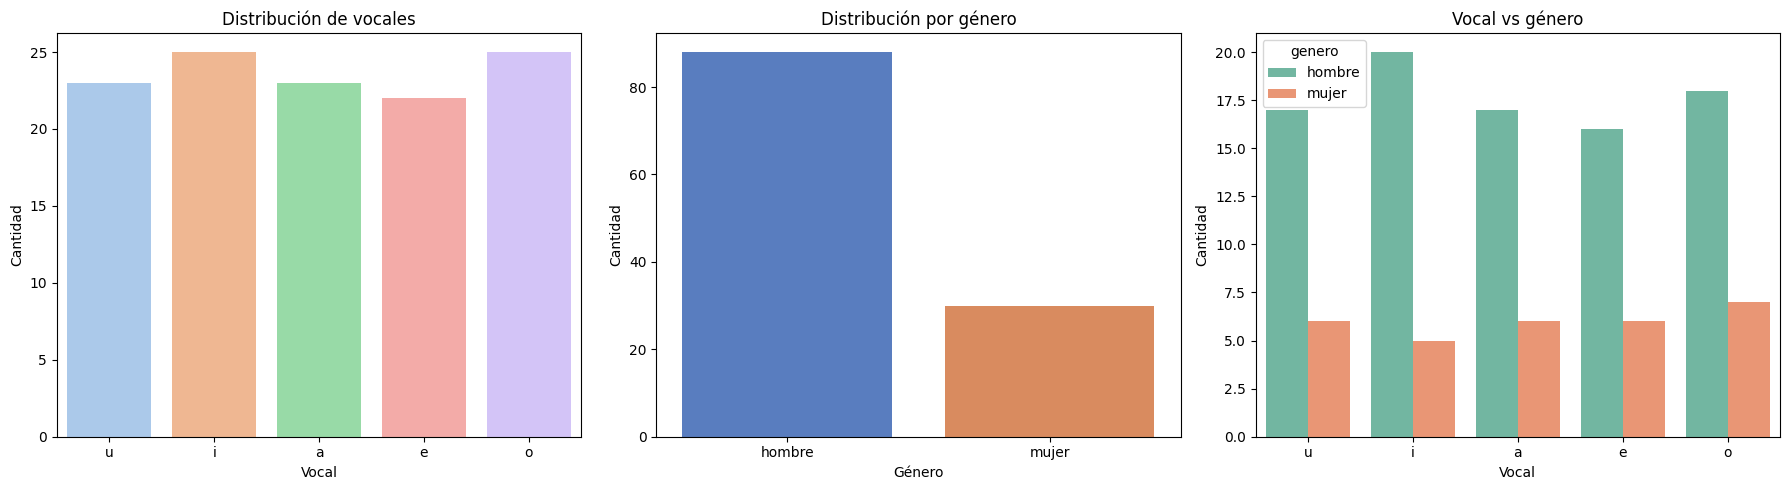

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.countplot(data=df_sin_silencio_outliers, x='vocal', palette="pastel", ax=axes[0])
axes[0].set_title("Distribución de vocales")
axes[0].set_xlabel("Vocal")
axes[0].set_ylabel("Cantidad")


sns.countplot(data=df_sin_silencio_outliers, x='genero', palette="muted", ax=axes[1])
axes[1].set_title("Distribución por género")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Cantidad")


sns.countplot(data=df_sin_silencio_outliers, x='vocal', hue='genero', palette="Set2", ax=axes[2])
axes[2].set_title("Vocal vs género")
axes[2].set_xlabel("Vocal")
axes[2].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

Con el dataset limpio, se estudió la distribución de las etiquetas para verificar que el
conjunto de datos fuera adecuado para el entrenamiento. Respecto a la variable objetivo,
la distribución por vocal resultó notablemente equilibrada, con entre 22 y 25 muestras por
clase. Este balance es una condición muy favorable, ya que evita que el modelo desarrolle
un sesgo hacia las clases con mayor representación y permite que la métrica de *accuracy*
sea una medida fiable del rendimiento global.

Sin embargo, al analizar la distribución por género se detectó un desbalance
significativo: 88 grabaciones pertenecen a locutores masculinos frente a 30 femeninas. Esto
supone una limitación real del dataset, dado que los formantes vocálicos —las frecuencias
de resonancia del tracto vocal que caracterizan a cada vocal— varían de forma sistemática
entre hombres y mujeres debido a las diferencias anatómicas en la longitud del tracto vocal.